# Data with Pandas 

In [1]:
import pandas as pd 
from matplotlib import pyplot as plt

In [2]:
from pathlib import Path

# Pfad zur Datei (relativ zum Notebook)
csv_path = Path("../data/eistage.csv")

df = pd.read_csv(
    csv_path,
    sep=";",                # Semikolon als Trennzeichen
    skiprows=[0, 1],             # erste Zeile (Beschreibungstext) überspringen
    low_memory=False,      # Warnung bei gemischten Datentypen unterdrücken
    encoding="utf-8",       # ggf. "latin-1" falls Umlaute kaputt sind
    usecols=[3, 5, 6],  # nur die Spalten "Datum", "Eistage" und "Eistage_5J" laden],
    nrows=70,
    names=["year", "heat_days", "ice_days"],
    parse_dates=["year"],
)

print(df.shape)
print(df.dtypes)
df.head()

(70, 3)
year         datetime64[ns]
heat_days             int64
ice_days              int64
dtype: object


,year,heat_days,ice_days
0,1955-01-01,1,25
1,1956-01-01,3,46
2,1957-01-01,10,20
3,1958-01-01,9,11
4,1959-01-01,5,17


## Überblick

In [3]:
df.head(2) #Ersten 2 Zeilen anzeigen

,year,heat_days,ice_days
0,1955-01-01,1,25
1,1956-01-01,3,46


In [4]:
df.tail(2) #Letzten 2 Zeilen anzeigen

,year,heat_days,ice_days
68,2023-01-01,32,2
69,2024-01-01,45,2


In [5]:
df.info() #Informationen über die Spalten und Datentypen anzeigen

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   year       70 non-null     datetime64[ns]
 1   heat_days  70 non-null     int64         
 2   ice_days   70 non-null     int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 1.8 KB


In [6]:
df.describe() #Statistische Kennzahlen für numerische Spalten anzeigen

,year,heat_days,ice_days
count,70,70.000000,70.000000
mean,1989-07-02 05:49:42.857142912,15.371429,20.414286
min,1955-01-01 00:00:00,0.000000,2.000000
25%,1972-04-01 12:00:00,6.500000,12.250000
50%,1989-07-02 12:00:00,13.000000,19.500000
75%,2006-10-01 18:00:00,21.000000,25.000000
max,2024-01-01 00:00:00,45.000000,63.000000
std,NaN,11.007470,12.062029


## Daten manipulieren

In [7]:
df["year"] #Auswahl einer einzelnen Spalte

0    1955-01-01
1    1956-01-01
2    1957-01-01
3    1958-01-01
4    1959-01-01
        ...    
65   2020-01-01
66   2021-01-01
67   2022-01-01
68   2023-01-01
69   2024-01-01
Name: year, Length: 70, dtype: datetime64[ns]

In [8]:
namelist = ["heat_days", "ice_days"] #Liste mit den Spaltennamen, die wir auswählen wollen

df[namelist]

,heat_days,ice_days
0,1,25
1,3,46
2,10,20
3,9,11
4,5,17
...,...,...
65,21,3
66,24,7
67,31,6
68,32,2


In [9]:
df[["heat_days", "ice_days"]] #Alternative Schreibweise für die Auswahl mehrerer Spalten

,heat_days,ice_days
0,1,25
1,3,46
2,10,20
3,9,11
4,5,17
...,...,...
65,21,3
66,24,7
67,31,6
68,32,2


Restriction

In [10]:
df.loc[df["heat_days"] > 10].loc[df["ice_days"] < 5] #Alle Zeilen auswählen, in denen es mehr als 10 Hitzetage und weniger als 5 Eistage gab

,year,heat_days,ice_days
19,1974-01-01,11,3
60,2015-01-01,42,2
64,2019-01-01,38,3
65,2020-01-01,21,3
68,2023-01-01,32,2
69,2024-01-01,45,2


In [11]:
df.iloc[4] # Auswahl der 5. Zeile (Index 4) mit iloc, da loc den Index "year" verwendet und nicht die Zeilennummern

year         1959-01-01 00:00:00
heat_days                      5
ice_days                      17
Name: 4, dtype: object

In [12]:
df["extremwetter_tage"] = df["heat_days"] + df["ice_days"] #Neue Spalte "extremwetter_tage" erstellen, die die Summe aus Hitzetagen und Eistagen enthält

In [13]:
df.head()

,year,heat_days,ice_days,extremwetter_tage
0,1955-01-01,1,25,26
1,1956-01-01,3,46,49
2,1957-01-01,10,20,30
3,1958-01-01,9,11,20
4,1959-01-01,5,17,22


<Axes: >

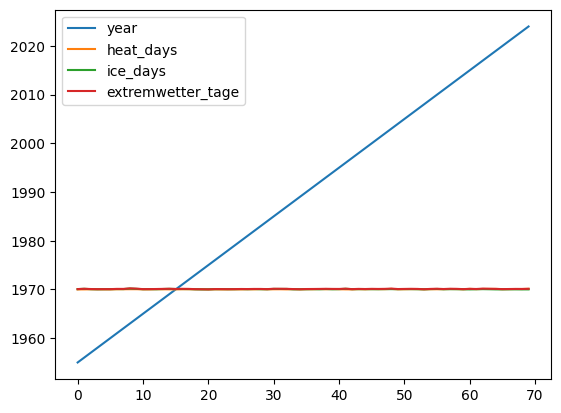

In [14]:
df.plot() #Einfaches Liniendiagramm aller numerischen Spalten über die Jahre erstellen (benötigt matplotlib)

<Axes: >

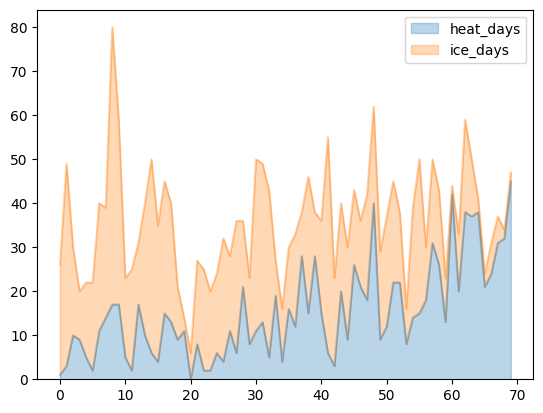

In [15]:
df[["heat_days", "ice_days"]].plot(kind="area", alpha=0.3) #Einfaches Liniendiagramm der Hitzetage über die Jahre erstellen (benötigt matplotlib)

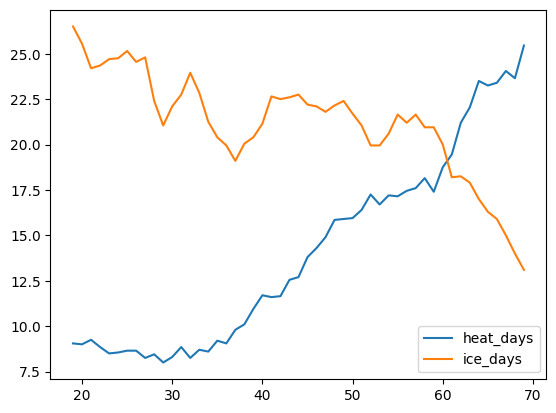

In [16]:
df[["heat_days", "ice_days"]].rolling(20).mean().plot()   #Gleitender Durchschnitt der Hitzetage über 5 Jahre berechnen, um den Trend zu glätten
plt.savefig("../image/heat_days_trend.png") #Plot als PNG-Datei im Ordner image speichern

<Axes: ylabel='Frequency'>

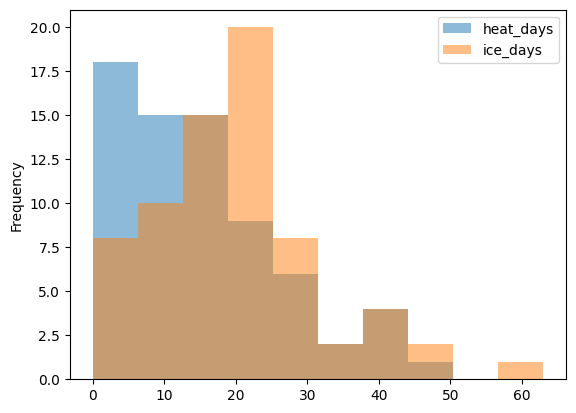

In [17]:
df[["heat_days", "ice_days"]].plot(kind="hist", alpha=0.5) #Histogramm der Hitzetage erstellen, um die Verteilung zu visualisieren

<Axes: >

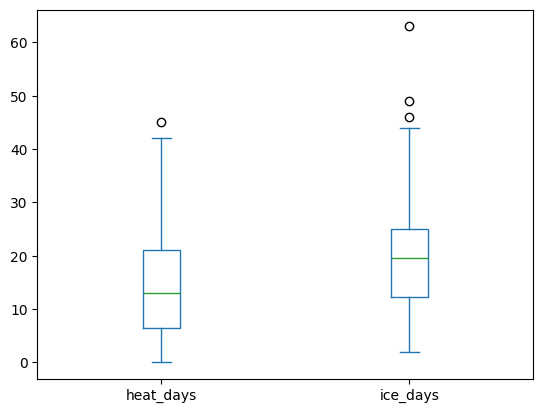

In [18]:
df[["heat_days", "ice_days"]].plot(kind="box") #Boxplot der Hitzetage erstellen, um die Verteilung und Ausreißer zu visualisieren

<Axes: xlabel='heat_days', ylabel='ice_days'>

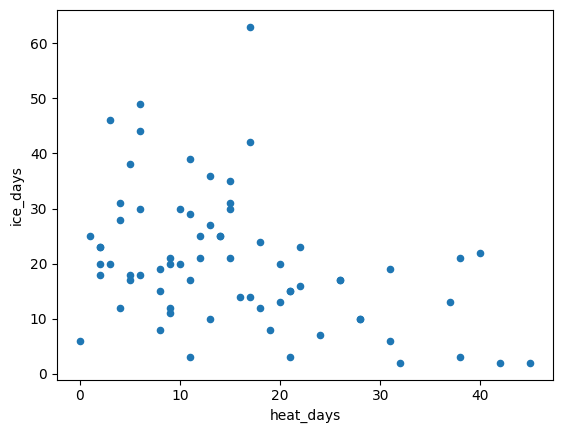

In [19]:
df[["heat_days", "ice_days"]].plot(kind="scatter", x="heat_days", y="ice_days") #Streudiagramm erstellen, um die Beziehung zwischen Hitzetagen und Eistagen zu visualisieren